# Topic-Hard Split Experiment (Notebook First)

This notebook upgrades the baseline clustering pipeline to:

1. Build topic vectors with **TF-IDF -> TruncatedSVD -> L2 normalization**.
2. Evaluate multiple `k` values (`[20, 30, 40, 50, 60, 80]`) using quality and balance diagnostics.
3. Choose a more usable clustering.
4. Simulate whole-cluster assignment to train/dev/test with a greedy objective.
5. Print split quality summaries **without writing files by default**.

Use this notebook to validate the method before creating an actual split file.

In [11]:
from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd


In [12]:
# Paths + experiment config
if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data.topic_hard_split import (
    _DEFAULT_BALANCE_BAND,
    _DEFAULT_K_VALUES,
    _RANDOM_STATE,
    add_usable_score,
    assign_clusters_to_splits,
    build_split_json,
    build_topic_vectors,
    choose_usable_k,
    evaluate_k_values,
    load_cleaned_data,
    plot_cluster_diagnostics,
    print_final_summary,
    save_split,
    select_cluster_examples,
    summarize_clusters,
    top_terms_by_cluster,
)

CLEANED_PATH = PROJECT_ROOT / "artifacts" / "data" / "cleaned.jsonl"
STANDARD_SPLIT_PATH = PROJECT_ROOT / "artifacts" / "splits" / "standard.json"
TOPIC_HARD_SPLIT_PATH = PROJECT_ROOT / "artifacts" / "splits" / "topic_hard.json"

RANDOM_STATE = _RANDOM_STATE
K_VALUES = list(_DEFAULT_K_VALUES)
BALANCE_BAND = _DEFAULT_BALANCE_BAND
TARGET_RATIOS = {"train": 0.8, "dev": 0.1, "test": 0.1}

# Safety switch: keep False during experimentation.
SAVE_SPLIT = True

df = load_cleaned_data(CLEANED_PATH)

print(f"Loaded {len(df):,} rows")
df.head()


Loaded 28,503 rows


,id,label,text
0,sar_000001,1,thirtysomething scientists unveil doomsday clo...
1,sar_000002,0,dem rep. totally nails why congress is falling...
2,sar_000003,0,eat your veggies: 9 deliciously different recipes
3,sar_000004,1,inclement weather prevents liar from getting t...
4,sar_000005,1,mother comes pretty close to using word 'strea...


In [13]:
def format_summary_table_for_display(summary_table: pd.DataFrame):
    formatted = summary_table.copy()

    def _format_value(value: float) -> str:
        value = float(value)
        if value.is_integer():
            return f"{int(value):,}"
        return f"{value:,.1f}"

    formatted["Value"] = formatted["Value"].map(_format_value)
    return formatted.style.hide(axis="index")


def format_examples_table_for_display(example_table: pd.DataFrame):
    return example_table.style.hide(axis="index")


In [14]:
x_tfidf, x_topic, vectorizer, reducer = build_topic_vectors(
    df["text"],
    max_features=20_000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    n_components=200,
    random_state=RANDOM_STATE,
)

print(f"TF-IDF shape: {x_tfidf.shape}")
print(f"Topic vector shape: {x_topic.shape}")

metrics_df, labels_by_k = evaluate_k_values(
    X_topic=x_topic,
    labels_true=df["label"],
    k_values=K_VALUES,
    random_state=RANDOM_STATE,
    silhouette_sample_size=5000,
)
metrics_df = add_usable_score(metrics_df)

metrics_df.sort_values("usable_score", ascending=False).reset_index(drop=True)


TF-IDF shape: (28503, 20000)
Topic vector shape: (28503, 200)


,k,inertia,silhouette,max_cluster_pct,min_cluster_pct,entropy_norm,mean_abs_label_skew,usable_score
0,80,18988.843581,0.136313,0.093780,0.003508,0.916936,0.144173,0.274629
1,60,20292.141094,0.116189,0.152440,0.004421,0.869711,0.162932,0.227581
2,50,21117.130076,0.106508,0.151914,0.003193,0.872925,0.162835,0.218690
3,40,21911.072203,0.094609,0.229906,0.006140,0.850259,0.158216,0.183452
4,30,22804.933311,0.081971,0.296004,0.006876,0.814650,0.167849,0.145723
5,20,23926.908321,0.066081,0.449567,0.009367,0.687895,0.187521,0.063140


In [15]:
chosen_k = choose_usable_k(metrics_df)
print(f"Chosen k: {chosen_k}")

df_clustered = df.copy()
df_clustered["cluster"] = labels_by_k[chosen_k]

df_clustered[["id", "label", "cluster", "text"]].head()

Chosen k: 80


,id,label,cluster,text
0,sar_000001,1,72,thirtysomething scientists unveil doomsday clo...
1,sar_000002,0,55,dem rep. totally nails why congress is falling...
2,sar_000003,0,5,eat your veggies: 9 deliciously different recipes
3,sar_000004,1,5,inclement weather prevents liar from getting t...
4,sar_000005,1,5,mother comes pretty close to using word 'strea...


In [16]:
summary_table_df, cluster_profile_df = summarize_clusters(
    df_clustered,
    balance_band=BALANCE_BAND,
)

print("Summary table for report/slide use")
display(format_summary_table_for_display(summary_table_df))


Summary table for report/slide use


Item,Value
Number of clusters chosen,80
Mean cluster size,356.3
Median cluster size,224
Smallest cluster,100
Largest cluster,"2,673"
# sarcasm-heavy clusters (>60% sarcasm),17
# near-balanced clusters (40-60% sarcasm),32
# non-sarcasm-heavy clusters (<40% sarcasm),31


Example clusters for appendix or backup slides


Example,Cluster,Size,Sarcasm %,Majority label,Top terms
Most sarcastic cluster,24,345,98.6%,sarcasm,"area, area man, man, girlfriend, got, area dad"
Most non-sarcastic cluster,30,427,4.2%,non-sarcasm,"donald, donald trump, trump, says, jr, trump says"
Most balanced cluster,53,250,50.0%,tied,"dead, dog, walking, walking dead, shelter, dead body"
Smallest cluster,61,100,24.0%,non-sarcasm,"morning, email, morning email, friday, friday morning, monday"
Largest cluster,5,2673,46.8%,non-sarcasm,"way, home, party, watch, really, star"


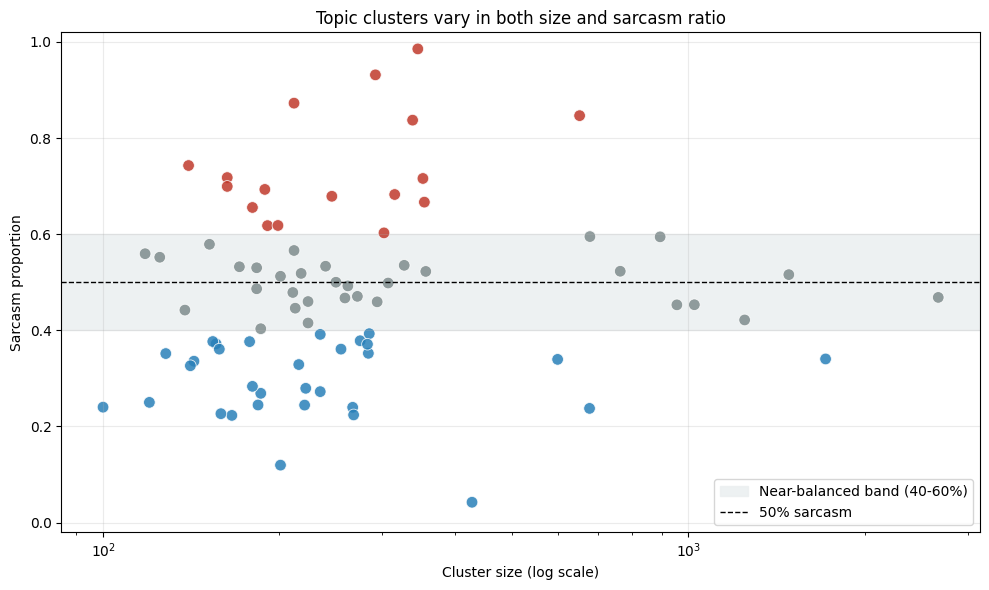

In [17]:
top_terms_df = top_terms_by_cluster(
    X_tfidf=x_tfidf,
    cluster_labels=df_clustered["cluster"].to_numpy(),
    vectorizer=vectorizer,
    top_n=12,
)

cluster_examples_df = select_cluster_examples(cluster_profile_df, top_terms_df)

print("Example clusters for appendix or backup slides")
display(format_examples_table_for_display(cluster_examples_df))

plot_cluster_diagnostics(
    cluster_profile_df,
    balance_band=BALANCE_BAND,
)


In [18]:
df_dryrun, cluster_to_split = assign_clusters_to_splits(
    df=df_clustered,
    split_ratios=TARGET_RATIOS,
    random_state=RANDOM_STATE,
)

print_final_summary(
    df_assigned=df_dryrun,
    cluster_to_split=cluster_to_split,
    target_ratios=TARGET_RATIOS,
)

split_sizes = df_dryrun["split"].value_counts().reindex(["train", "dev", "test"])
split_sizes



=== Final topic-hard split summary ===
Global label_1 ratio: 0.475

TRAIN (22875 rows, 0.803 vs target 0.80)
  label_0: 0.515
  label_1: 0.485
  n_clusters: 67

DEV (2774 rows, 0.097 vs target 0.10)
  label_0: 0.588
  label_1: 0.412
  n_clusters: 6

TEST (2854 rows, 0.100 vs target 0.10)
  label_0: 0.540
  label_1: 0.460
  n_clusters: 7


split
train    22875
dev       2774
test      2854
Name: count, dtype: int64

In [19]:
# Optional write step (disabled by default).
if SAVE_SPLIT:
    split_obj = build_split_json(
        df_assigned=df_dryrun,
        cluster_to_split=cluster_to_split,
        metrics=metrics_df,
        chosen_k=chosen_k,
        split_ratios=TARGET_RATIOS,
        random_state=RANDOM_STATE,
    )

    output_path = save_split(split_obj, TOPIC_HARD_SPLIT_PATH)
    print(f"Saved split -> {output_path}")
else:
    print("SAVE_SPLIT=False: dry-run only, no split file written.")


Saved split -> e:\CS4248_Project\artifacts\splits\topic_hard.json
